In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis


# Semente para os resultados serem reproduzíveis
np.random.seed(42)

In [17]:
# ============================================================
# Valores teóricos
# ============================================================

teoricos_uniforme = {
    "Média": 1.5,
    "Mediana": 1.5,
    "Moda estimada": np.nan,   # Uniforme não possui moda única
    "Variância": 6.75,
    "Assimetria": 0,
    "Curtose": -1.2
}

teoricos_normal = {
    "Média": 3,
    "Mediana": 3,
    "Moda estimada": 3,
    "Variância": 4,
    "Assimetria": 0,
    "Curtose": 0
}

# ============================================================
# Função para estimar a moda de uma variável contínua
# ============================================================

def moda_histograma(x, bins=30):
    """
    Estima a moda usando o intervalo mais frequente do histograma.

    Retorna o ponto médio do intervalo com maior frequência.
    """

    frequencias, bordas = np.histogram(x, bins=bins)

    indice_maior = np.argmax(frequencias)

    limite_inferior = bordas[indice_maior]
    limite_superior = bordas[indice_maior + 1]

    moda = (limite_inferior + limite_superior) / 2

    return moda


# ============================================================
# Função para calcular as estatísticas
# ============================================================

def calcular_estatisticas(x, bins_moda=30):

    return {
        "Média": np.mean(x),
        "Mediana": np.median(x),
        "Moda estimada": moda_histograma(x, bins=bins_moda),

        # ddof=1 -> variância amostral
        "Variância": np.var(x, ddof=1),

        "Assimetria": skew(x, bias=False),

        # fisher=True:
        # normal -> curtose excedente = 0
        "Curtose": kurtosis(
            x,
            fisher=True,
            bias=False
        )
    }

def comparar_com_teorico(estatisticas, teoricos):
    comparacao = []

    for medida, valor_amostral in estatisticas.items():
        valor_teorico = teoricos[medida]

        # Caso especial: não existe valor teórico único
        if np.isnan(valor_teorico):
            erro_absoluto = np.nan
            erro_relativo = np.nan
        else:
            erro_absoluto = abs(valor_amostral - valor_teorico)

            # Evita divisão por zero
            if valor_teorico != 0:
                erro_relativo = (
                    erro_absoluto / abs(valor_teorico)
                ) * 100
            else:
                erro_relativo = np.nan

        comparacao.append({
            "Estatística": medida,
            "Amostral": valor_amostral,
            "Teórico": valor_teorico,
            "Erro absoluto": erro_absoluto,
            "Erro relativo (%)": erro_relativo
        })

    return pd.DataFrame(comparacao)

In [18]:
# ============================================================
# Generate random variables
# ============================================================

def generate_random_variables(n=1000):
    resultados = []

    # --------------------------------------------------------
    # Distribuição uniforme
    # --------------------------------------------------------

    xU = np.random.uniform(
        low=-3,
        high=6,
        size=n
    )

    # --------------------------------------------------------
    # Distribuição normal
    # --------------------------------------------------------

    xN = np.random.normal(
        loc=3,       # média
        scale=2,     # desvio padrão
        size=n
    )

    # --------------------------------------------------------
    # Estatísticas
    # --------------------------------------------------------

    estat_U = calcular_estatisticas(xU)
    estat_N = calcular_estatisticas(xN)

    comparacao_U = comparar_com_teorico(
        estat_U,
        teoricos_uniforme
    )

    comparacao_N = comparar_com_teorico(
        estat_N,
        teoricos_normal
    )

    resultados.append({
        "N": n,
        "Distribuição": "Uniforme",
        **estat_U
    })

    resultados.append({
        "N": n,
        "Distribuição": "Normal",
        **estat_N
    })

    print("\n===================================")
    print(f"Distribuição Uniforme - N = {n}")
    print("===================================")
    print(comparacao_U.round(4))

    print("\n===================================")
    print(f"Distribuição Normal - N = {n}")
    print("===================================")
    print(comparacao_N.round(4))

    # ========================================================
    # Gráficos
    # ========================================================

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(12, 8)
    )

    # --------------------------------------------------------
    # Histograma uniforme
    # --------------------------------------------------------

    axes[0, 0].hist(
        xU,
        bins=30,
        edgecolor="black",
        density=True
    )

    axes[0, 0].set_title(
        f"Histograma - Uniforme U(-3, 6) - N = {n:,}"
    )

    axes[0, 0].set_xlabel("x")
    axes[0, 0].set_ylabel("Densidade")

    # --------------------------------------------------------
    # Boxplot uniforme
    # --------------------------------------------------------

    axes[1, 0].boxplot(
        xU,
        vert=False
    )

    axes[1, 0].set_title(
        f"Boxplot - Uniforme - N = {n:,}"
    )

    axes[1, 0].set_xlabel("x")

    # --------------------------------------------------------
    # Histograma normal
    # --------------------------------------------------------

    axes[0, 1].hist(
        xN,
        bins=30,
        edgecolor="black",
        density=True
    )

    axes[0, 1].set_title(
        f"Histograma - Normal N(3, 2²) - N = {n:,}"
    )

    axes[0, 1].set_xlabel("x")
    axes[0, 1].set_ylabel("Densidade")

    # --------------------------------------------------------
    # Boxplot normal
    # --------------------------------------------------------

    axes[1, 1].boxplot(
        xN,
        vert=False
    )

    axes[1, 1].set_title(
        f"Boxplot - Normal - N = {n:,}"
    )

    axes[1, 1].set_xlabel("x")

    plt.tight_layout()
    plt.show()

    return resultados



Distribuição Uniforme - N = 1000
     Estatística  Amostral  Teórico  Erro absoluto  Erro relativo (%)
0          Média    1.6893     1.50         0.1893            12.6173
1        Mediana    1.7639     1.50         0.2639            17.5914
2  Moda estimada    5.8425      NaN            NaN                NaN
3      Variância    6.8139     6.75         0.0639             0.9463
4     Assimetria   -0.0718     0.00         0.0718                NaN
5        Curtose   -1.2012    -1.20         0.0012             0.0974

Distribuição Normal - N = 1000
     Estatística  Amostral  Teórico  Erro absoluto  Erro relativo (%)
0          Média    2.9811        3         0.0189             0.6286
1        Mediana    2.9902        3         0.0098             0.3270
2  Moda estimada    2.9955        3         0.0045             0.1513
3      Variância    4.1456        4         0.1456             3.6392
4     Assimetria   -0.0407        0         0.0407                NaN
5        Curtose    0.00

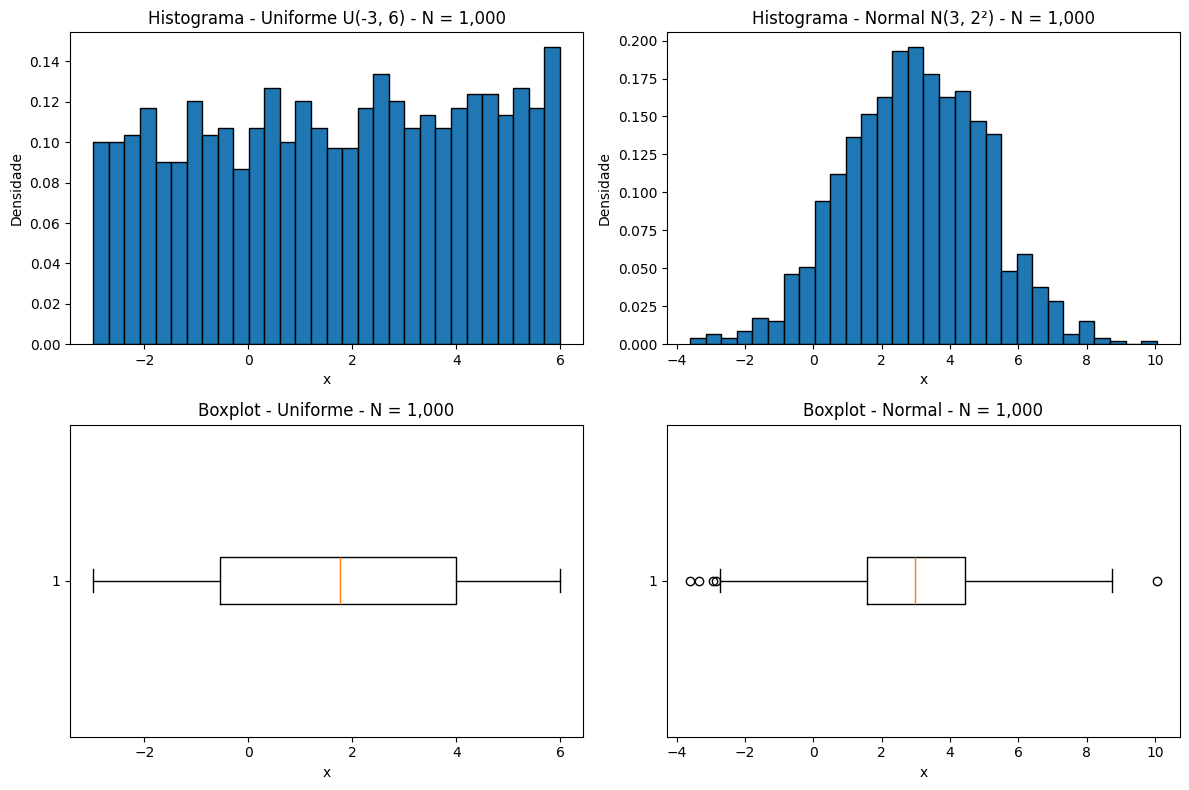

In [21]:

# ============================================================
# Questão 1. a e b
# ============================================================

# Números de amostras 1000
resultados = generate_random_variables(1000)


Distribuição Uniforme - N = 10000
     Estatística  Amostral  Teórico  Erro absoluto  Erro relativo (%)
0          Média    1.5261     1.50         0.0261             1.7401
1        Mediana    1.5093     1.50         0.0093             0.6199
2  Moda estimada    2.8493      NaN            NaN                NaN
3      Variância    6.6719     6.75         0.0781             1.1574
4     Assimetria   -0.0081     0.00         0.0081                NaN
5        Curtose   -1.1786    -1.20         0.0214             1.7802

Distribuição Normal - N = 10000
     Estatística  Amostral  Teórico  Erro absoluto  Erro relativo (%)
0          Média    2.9984        3         0.0016             0.0541
1        Mediana    3.0246        3         0.0246             0.8204
2  Moda estimada    3.4428        3         0.4428            14.7591
3      Variância    3.9489        4         0.0511             1.2787
4     Assimetria   -0.0436        0         0.0436                NaN
5        Curtose    0.

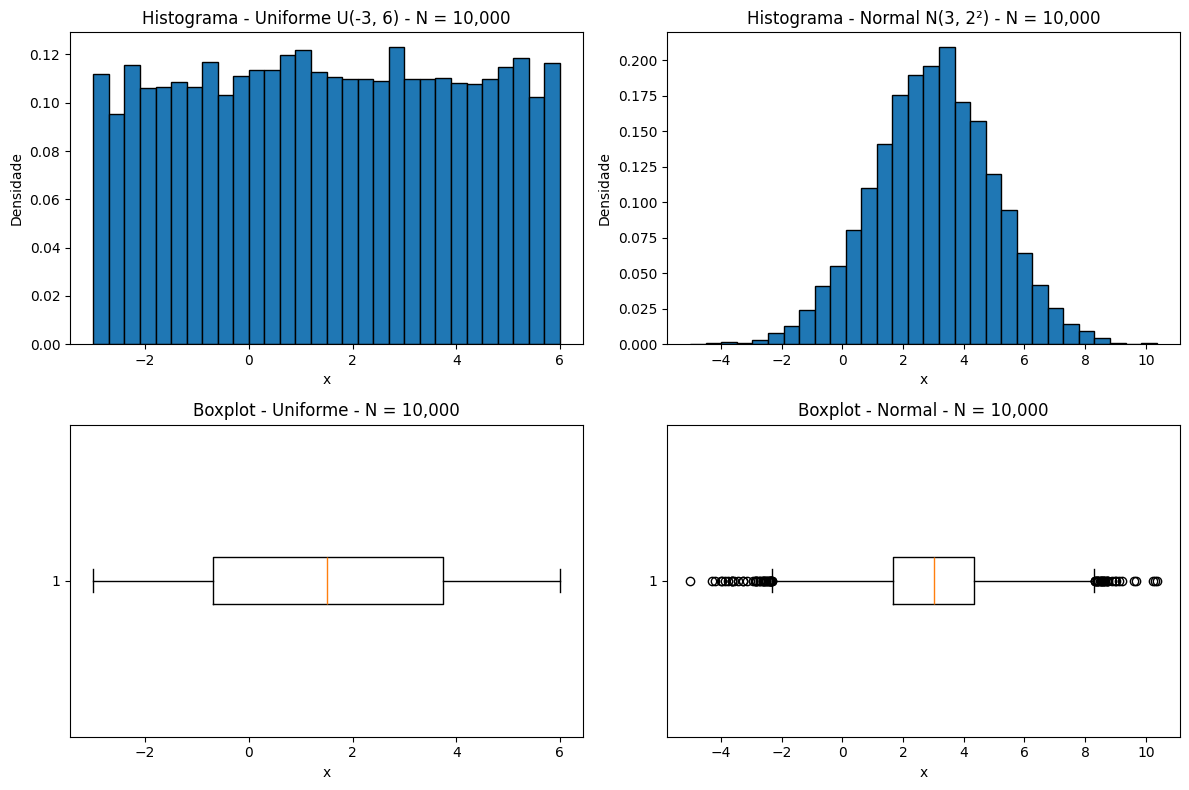


Distribuição Uniforme - N = 100000
     Estatística  Amostral  Teórico  Erro absoluto  Erro relativo (%)
0          Média    1.4920     1.50         0.0080             0.5325
1        Mediana    1.4874     1.50         0.0126             0.8409
2  Moda estimada   -1.0500      NaN            NaN                NaN
3      Variância    6.7453     6.75         0.0047             0.0692
4     Assimetria    0.0035     0.00         0.0035                NaN
5        Curtose   -1.2027    -1.20         0.0027             0.2209

Distribuição Normal - N = 100000
     Estatística  Amostral  Teórico  Erro absoluto  Erro relativo (%)
0          Média    3.0005        3         0.0005             0.0159
1        Mediana    3.0059        3         0.0059             0.1963
2  Moda estimada    2.8796        3         0.1204             4.0139
3      Variância    4.0084        4         0.0084             0.2112
4     Assimetria   -0.0093        0         0.0093                NaN
5        Curtose   -

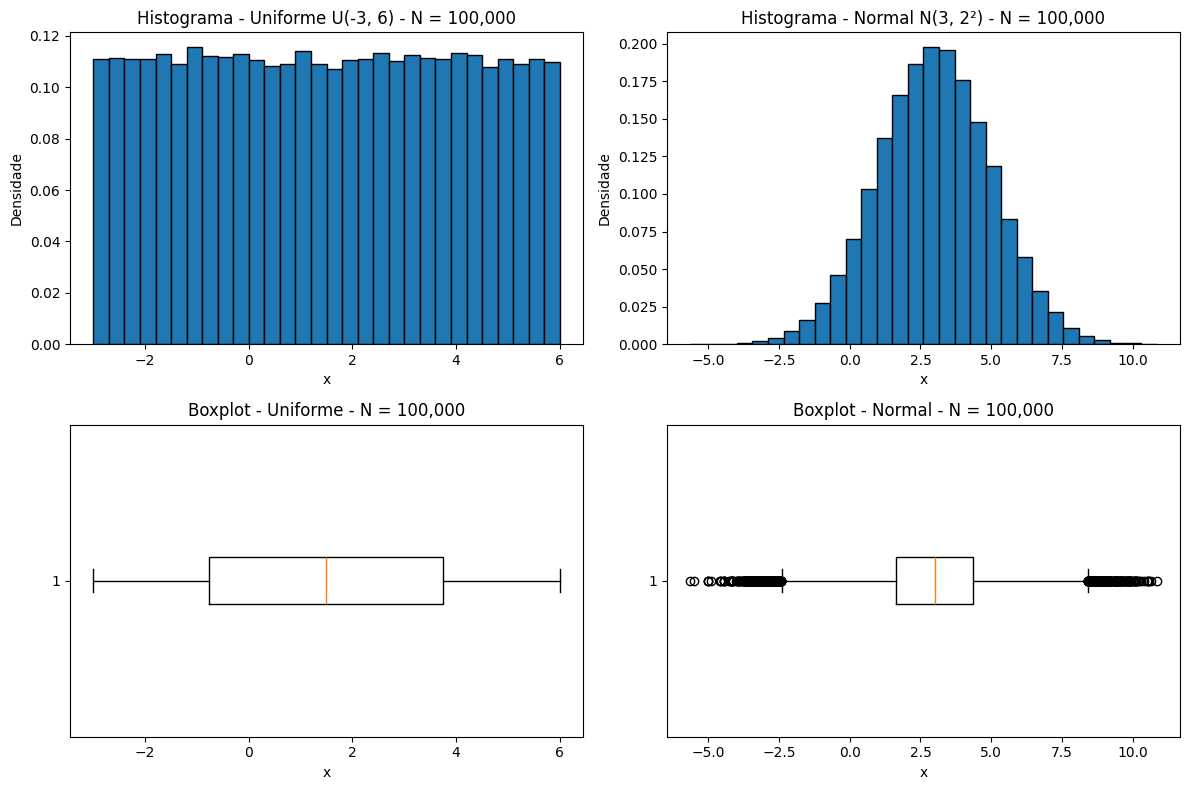


Resultados obtidos:
     N Distribuição  Média  Mediana  Moda estimada  Variância  Assimetria  Curtose
  1000     Uniforme 1.6893   1.7639         5.8425     6.8139     -0.0718  -1.2012
  1000       Normal 2.9811   2.9902         2.9955     4.1456     -0.0407   0.0018
 10000     Uniforme 1.5261   1.5093         2.8493     6.6719     -0.0081  -1.1786
 10000       Normal 2.9984   3.0246         3.4428     3.9489     -0.0436   0.0286
100000     Uniforme 1.4920   1.4874        -1.0500     6.7453      0.0035  -1.2027
100000       Normal 3.0005   3.0059         2.8796     4.0084     -0.0093  -0.0040


In [22]:
# ============================================================
# Questão 1. c e d
# ============================================================

# Números de amostras 10000
resultados10000 = generate_random_variables(10000)

# Números de amostras 10000
resultados100000 = generate_random_variables(100000)

# ============================================================
# Criando tabela com todos os resultados
# ============================================================

# Junta todos os resultados
resultados = (
    resultados
    + resultados10000
    + resultados100000
)

# Cria DataFrame
df_resultados = pd.DataFrame(resultados)

print("\nResultados obtidos:")
print(df_resultados.round(4).to_string(index=False))

In [ ]:
Percebemos que, partir dos resultados, à medida que o número de amostras aumenta, a média tende a se aproximar do valor teórico em ambas as distribuições.
Na distribuição uniforme, a média converge para o valor teórico de 1,5, enquanto, na distribuição normal, converge para 3. Esse comportamento esperado,
uma vez que o aumento do numero de amostra reduz o efeito das flutuações aleatórias